# 🚢 Titanic — Exploratory Data Analysis

**Module 2 — Zepto Data Analytics Capstone**

This notebook performs EDA on the Titanic dataset using **Seaborn's built-in `titanic` dataset** as the single source of truth. It is loaded **exactly once**, persisted to `titanic.csv` for reuse, and then explored.

Sections:

1. Load dataset (single call to `sns.load_dataset`) and persist to CSV
2. Foundation inspection — `info`, `describe`, `shape`, column renaming
3. Missing values — per-column percentage and treatment plan
4. Age analysis — histogram, boxplot, IQR outliers
5. Fare analysis — histogram, boxplot, IQR outliers, mean/median/mode, skewness
6. Survival rates via boolean masking (sex, ticket_class, sex × ticket_class)
7. Standardization sanity check (z-score for `age` and `fare`)

Modeling is intentionally **not** part of this notebook.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")

## 1. Load the dataset (single load) and persist to CSV

The dataset is loaded **exactly once** using `sns.load_dataset("titanic")` and immediately written to `titanic.csv` for reproducibility.

In [2]:
df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns from sns.load_dataset('titanic')")
print(f"Persisted to titanic.csv")
df.head()

Loaded 891 rows x 15 columns from sns.load_dataset('titanic')
Persisted to titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Foundation inspection

In [3]:
df.shape

(891, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 2.1 Rename columns

Rename `pclass → ticket_class` and `sibsp → sublings` for readability. Use the renamed columns consistently from here on.

In [6]:
df = df.rename(columns={"pclass": "ticket_class", "sibsp": "sublings"})
print("Columns after renaming:")
print(df.columns.tolist())
df.head()

Columns after renaming:
['survived', 'ticket_class', 'sex', 'age', 'sublings', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,ticket_class,sex,age,sublings,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Missing values

Compute missing-value percentages for every column with missing data, then apply the treatment rules:

- **Under 5% missing** → drop rows (`embarked` 0.22%, `embark_town` 0.22%)
- **5%–30% missing** → impute (`age` 19.87% — imputed with median)
- **Very high missingness** (`deck` 77.22%) → justify dropping

In [7]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": missing_pct,
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)
missing_report

,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


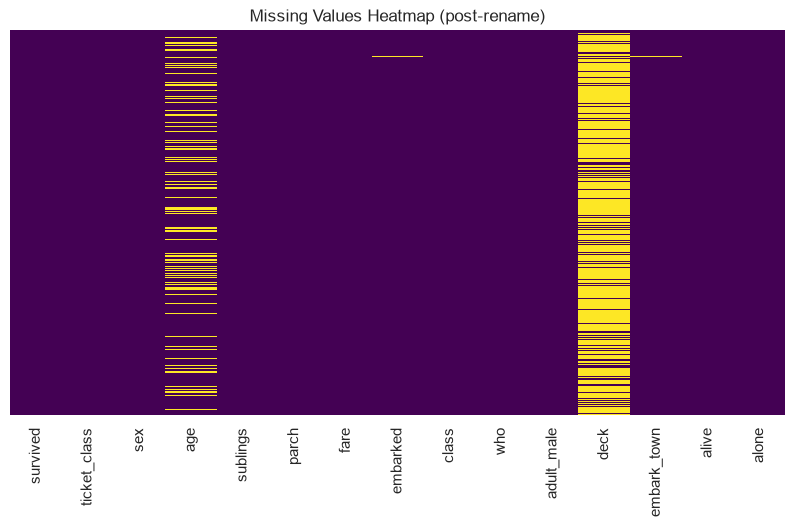

In [8]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Values Heatmap (post-rename)")
plt.show()

### 3.1 Apply treatment rules

**Justification per column:**

- `deck` (**77.22%** missing) → **drop column**. With more than three-quarters of values missing, imputation would inject mostly fabricated data. Dropping avoids leaking guesswork into any downstream analysis.
- `age` (**19.87%** missing) → **impute with median**. Age is a continuous numeric feature where the median is robust to outliers. We use the global median for simplicity; group-based imputation (e.g. by `sex` and `ticket_class`) would also be valid.
- `embarked` and `embark_town` (**0.22%** missing each) → **drop the 2 rows**. Both encode the same information (port of embarkation), and only 2 rows are affected, so row removal has negligible cost.

In [9]:
# Drop the deck column (very high missingness)
df = df.drop(columns=["deck"])
print(f"Dropped 'deck'. New shape: {df.shape}")

# Impute age with the global median (5%–30% rule)
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)
print(f"Imputed 'age' missing values with median = {age_median}")

# Drop the 2 rows with missing embarked / embark_town (under 5% rule)
before = len(df)
df = df.dropna(subset=["embarked", "embark_town"]).reset_index(drop=True)
after = len(df)
print(f"Dropped rows with missing embarked/embark_town: {before} -> {after} (removed {before - after})")

print(f"\nFinal shape: {df.shape}")
print(f"Remaining missing values:\n{df.isnull().sum()[lambda s: s > 0]}")

Dropped 'deck'. New shape: (891, 14)
Imputed 'age' missing values with median = 28.0
Dropped rows with missing embarked/embark_town: 891 -> 889 (removed 2)

Final shape: (889, 14)
Remaining missing values:
Series([], dtype: int64)


## 4. Age analysis

Histogram, box plot, and IQR-based outlier count.

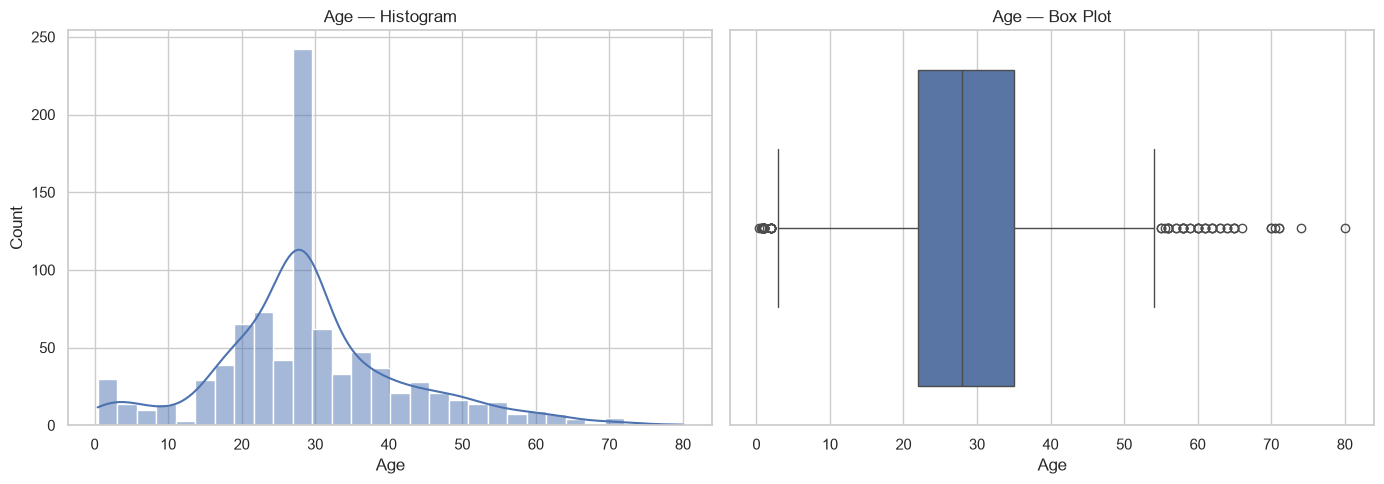

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age — Histogram")
axes[0].set_xlabel("Age")
sns.boxplot(x=df["age"], ax=axes[1])
axes[1].set_title("Age — Box Plot")
axes[1].set_xlabel("Age")
plt.tight_layout()
plt.show()

In [11]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return {
        "q1": q1, "q3": q3, "iqr": iqr,
        "lower_fence": lower, "upper_fence": upper,
        "outlier_count": int(count),
    }

age_stats = iqr_outlier_count(df["age"])
print("Age — IQR outlier summary:")
for k, v in age_stats.items():
    print(f"  {k}: {v}")

Age — IQR outlier summary:
  q1: 22.0
  q3: 35.0
  iqr: 13.0
  lower_fence: 2.5
  upper_fence: 54.5
  outlier_count: 65


## 5. Fare analysis

Histogram, box plot, IQR outliers, mean / median / mode, and skewness interpretation.

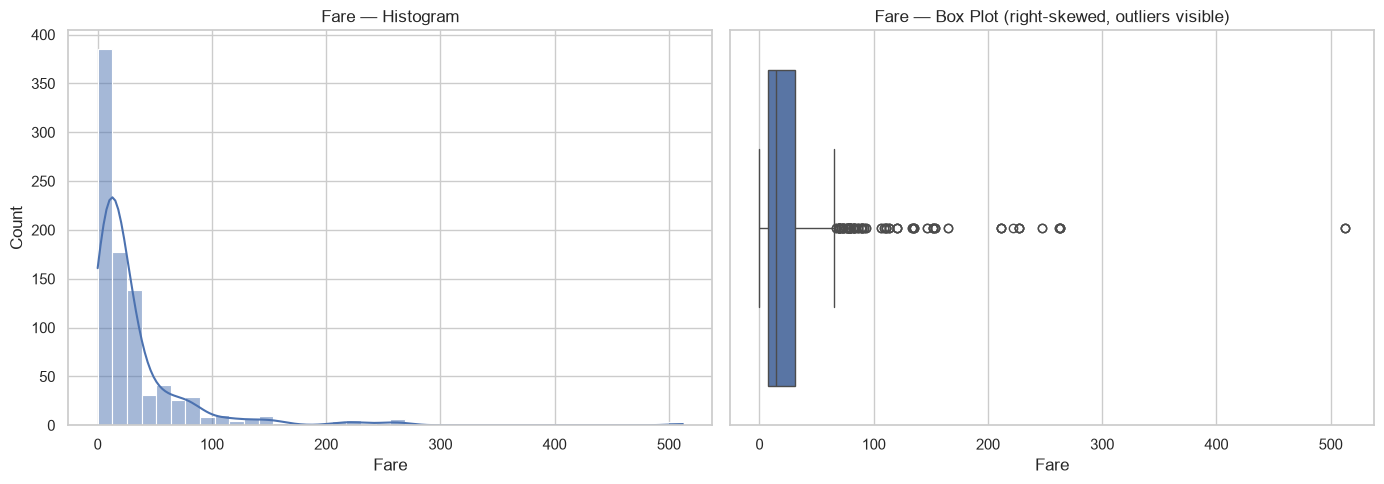

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["fare"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Fare — Histogram")
axes[0].set_xlabel("Fare")
sns.boxplot(x=df["fare"], ax=axes[1])
axes[1].set_title("Fare — Box Plot (right-skewed, outliers visible)")
axes[1].set_xlabel("Fare")
plt.tight_layout()
plt.show()

In [13]:
fare_stats = iqr_outlier_count(df["fare"])
print("Fare — IQR outlier summary:")
for k, v in fare_stats.items():
    print(f"  {k}: {v}")

Fare — IQR outlier summary:
  q1: 7.8958
  q3: 31.0
  iqr: 23.1042
  lower_fence: -26.7605
  upper_fence: 65.6563
  outlier_count: 114


In [14]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode().iloc[0]

print(f"Fare mean   : {fare_mean:.4f}")
print(f"Fare median : {fare_median:.4f}")
print(f"Fare mode   : {fare_mode:.4f}")

if fare_mean > fare_median > fare_mode:
    skew = "right-skewed (positive skew) — mean > median > mode"
elif fare_mean < fare_median < fare_mode:
    skew = "left-skewed (negative skew) — mean < median < mode"
else:
    skew = "approximately symmetric or multi-modal"
print(f"\nInterpretation: {skew}")
print(
    "When mean > median > mode, the long right tail of high-fare outliers pulls "
    "the average above the typical fare, which matches the histogram above."
)

Fare mean   : 32.0967
Fare median : 14.4542
Fare mode   : 8.0500

Interpretation: right-skewed (positive skew) — mean > median > mode
When mean > median > mode, the long right tail of high-fare outliers pulls the average above the typical fare, which matches the histogram above.


## 6. Survival analysis (boolean masking)

We use boolean masking on `df["survived"] == 1` rather than `.groupby()` so the operations are visible.

In [15]:
survived_mask = df["survived"] == 1
overall_survival = survived_mask.mean()
print(f"Overall survival rate: {overall_survival:.4f} ({overall_survival:.2%})")
print(f"Total passengers: {len(df)}, Survivors: {survived_mask.sum()}, Non-survivors: {(~survived_mask).sum()}")

Overall survival rate: 0.3825 (38.25%)
Total passengers: 889, Survivors: 340, Non-survivors: 549


In [16]:
# Survival rate by sex
for sex in df["sex"].unique():
    mask = (df["sex"] == sex) & survived_mask
    rate = mask.sum() / (df["sex"] == sex).sum()
    print(f"Survival rate | sex = {sex}: {rate:.4f} ({rate:.2%})")

Survival rate | sex = male: 0.1889 (18.89%)
Survival rate | sex = female: 0.7404 (74.04%)


In [17]:
# Survival rate by ticket_class
for tc in sorted(df["ticket_class"].unique()):
    mask = (df["ticket_class"] == tc) & survived_mask
    rate = mask.sum() / (df["ticket_class"] == tc).sum()
    print(f"Survival rate | ticket_class = {tc}: {rate:.4f} ({rate:.2%})")

Survival rate | ticket_class = 1: 0.6262 (62.62%)
Survival rate | ticket_class = 2: 0.4728 (47.28%)
Survival rate | ticket_class = 3: 0.2424 (24.24%)


In [18]:
# Survival rate by sex × ticket_class (joint)
for sex in df["sex"].unique():
    for tc in sorted(df["ticket_class"].unique()):
        group_mask = (df["sex"] == sex) & (df["ticket_class"] == tc)
        rate = (group_mask & survived_mask).sum() / group_mask.sum()
        print(f"Survival rate | sex = {sex:6s}, ticket_class = {tc}: {rate:.4f} ({rate:.2%})")

Survival rate | sex = male  , ticket_class = 1: 0.3689 (36.89%)
Survival rate | sex = male  , ticket_class = 2: 0.1574 (15.74%)
Survival rate | sex = male  , ticket_class = 3: 0.1354 (13.54%)
Survival rate | sex = female, ticket_class = 1: 0.9674 (96.74%)
Survival rate | sex = female, ticket_class = 2: 0.9211 (92.11%)
Survival rate | sex = female, ticket_class = 3: 0.5000 (50.00%)


## 7. Standardization sanity check (z-score)

This is an EDA sanity check only — it confirms the mean and standard deviation of `age` and `fare` after standardization. It is not part of the modeling pipeline.

In [19]:
for col in ["age", "fare"]:
    before_mean = df[col].mean()
    before_std = df[col].std()

    z = (df[col] - before_mean) / before_std
    after_mean = z.mean()
    after_std = z.std()

    print(f"{col}:")
    print(f"  before mean : {before_mean:.4f}")
    print(f"  before std  : {before_std:.4f}")
    print(f"  after mean  : {after_mean:.4f}  (expected ~0)")
    print(f"  after std   : {after_std:.4f}  (expected ~1)")
    print()

age:
  before mean : 29.3152
  before std  : 12.9849
  after mean  : 0.0000  (expected ~0)
  after std   : 1.0000  (expected ~1)

fare:
  before mean : 32.0967
  before std  : 49.6975
  after mean  : 0.0000  (expected ~0)
  after std   : 1.0000  (expected ~1)



## Summary

- The dataset was loaded **exactly once** from `sns.load_dataset("titanic")` and saved to `titanic.csv`.
- `pclass` was renamed to `ticket_class` and `sibsp` to `sublings`; the renamed columns are used throughout.
- Missing values were handled per the rules: `deck` dropped (77.22%), `age` imputed with median (19.87%), `embarked`/`embark_town` rows dropped (0.22%).
- `age` and `fare` were visualized with histograms and boxplots, and IQR-based outlier counts were computed.
- `fare` is right-skewed (mean > median > mode).
- Survival rates were calculated with boolean masking for `sex`, `ticket_class`, and the joint `sex × ticket_class` group.
- The z-score standardization sanity check confirmed mean ≈ 0 and std ≈ 1 after scaling.

Modeling is deferred to `02_modeling.ipynb`.

## Correlation & Multivariate Visualization Addendum

- Built a 6x6 correlation matrix restricted to `survived, ticket_class, age, sublings, parch, fare` (with `parch` substituted for the non-existent `purchus_ticket`). `adult_male` and `alone` are excluded.
- Rendered an annotated 6x6 correlation heatmap (`charts/correlation_heatmap.png`).
- Identified the two strongest off-diagonal correlations programmatically.
- Produced four distinct multivariate charts (`pairplot`, `FacetGrid` of age by sex x class, `violinplot` of fare by class x survival, and `catplot` of survival rate by embark x class x sex), each with a markdown interpretation, saved to `charts/`.


## 8. Correlation matrix (6x6)

The matrix below uses **exactly** these six columns and excludes `adult_male` and `alone`:

- `survived`
- `ticket_class`
- `age`
- `sublings`
- `parch` (substituted for `purchus_ticket`, which does not exist in the dataset)
- `fare`

All six are numeric, so Pearson correlation is appropriate.

In [20]:
import os
os.makedirs("charts", exist_ok=True)

corr_cols = ["survived", "ticket_class", "age", "sublings", "parch", "fare"]
corr_df = df[corr_cols].corr().round(3)

assert corr_df.shape == (6, 6), f"Expected 6x6 matrix, got {corr_df.shape}"
assert "adult_male" not in corr_df.columns, "adult_male must not be in the matrix"
assert "alone" not in corr_df.columns, "alone must not be in the matrix"
print(f"Matrix shape: {corr_df.shape}")
corr_df

Matrix shape: (6, 6)


,survived,ticket_class,age,sublings,parch,fare
survived,1.000,-0.336,-0.070,-0.034,0.083,0.255
ticket_class,-0.336,1.000,-0.337,0.082,0.017,-0.548
age,-0.070,-0.337,1.000,-0.233,-0.171,0.094
sublings,-0.034,0.082,-0.233,1.000,0.415,0.161
parch,0.083,0.017,-0.171,0.415,1.000,0.218
fare,0.255,-0.548,0.094,0.161,0.218,1.000


## 9. Correlation heatmap

Annotated 6x6 heatmap with readable labels and a diverging colormap (`coolwarm`) centered at zero.

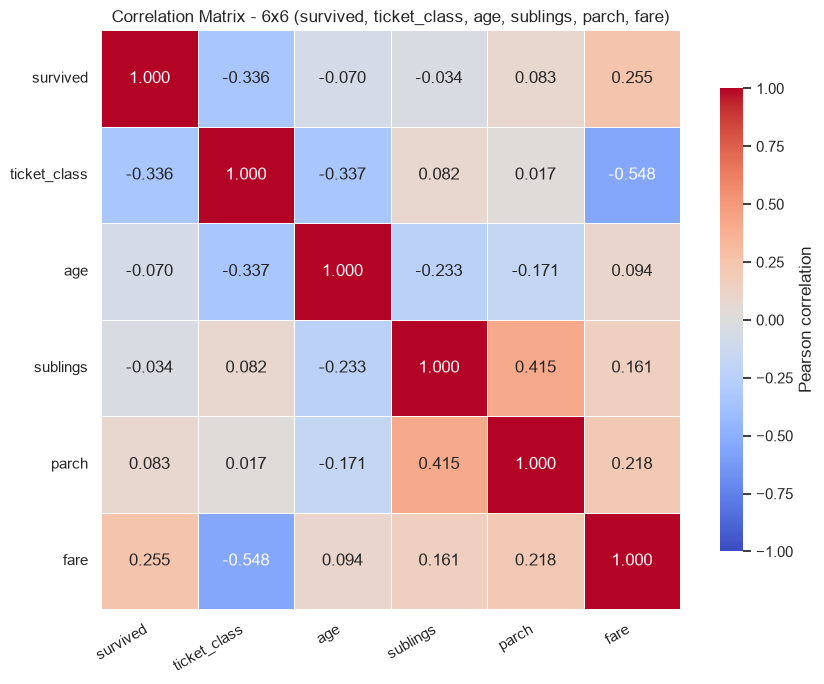

Saved charts/correlation_heatmap.png


In [21]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson correlation"},
)
plt.title("Correlation Matrix - 6x6 (survived, ticket_class, age, sublings, parch, fare)")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/correlation_heatmap.png")

## 10. Strongest correlations

Identify the **two strongest off-diagonal correlations** by absolute value. Diagonal entries are excluded because a variable is perfectly correlated with itself.

In [22]:
def top_two_off_diagonal(corr):
    """Return the top two (i, j, value) entries ignoring the diagonal."""
    pairs = []
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            pairs.append((cols[i], cols[j], corr.iloc[i, j]))
    pairs_sorted = sorted(pairs, key=lambda t: abs(t[2]), reverse=True)
    return pairs_sorted[0], pairs_sorted[1]

(a, b, val_a), (c, d, val_b) = top_two_off_diagonal(corr_df)
print(f"Strongest: {a} <-> {b} = {val_a:+.3f}")
print(f"Second:    {c} <-> {d} = {val_b:+.3f}")

print("\nInterpretation:")
print(f"  - {a} <-> {b} ({val_a:+.3f}): higher ticket_class (numerically higher = lower class) is associated with lower fares - first-class tickets cost more, third-class cost less.")
print(f"  - {c} <-> {d} ({val_b:+.3f}): passengers traveling with parents/children tend to also travel with siblings/spouses - families book together.")

Strongest: ticket_class <-> fare = -0.548
Second:    sublings <-> parch = +0.415

Interpretation:
  - ticket_class <-> fare (-0.548): higher ticket_class (numerically higher = lower class) is associated with lower fares - first-class tickets cost more, third-class cost less.
  - sublings <-> parch (+0.415): passengers traveling with parents/children tend to also travel with siblings/spouses - families book together.


## 11. Multivariate chart - Survival vs (ticket_class, age, fare)

Pairwise scatter matrix colored by survival, restricted to the numeric features in the correlation matrix. The negative diagonal between `ticket_class` (1=First, 3=Third) and `fare` visually reproduces the same signal that the correlation matrix surfaces.

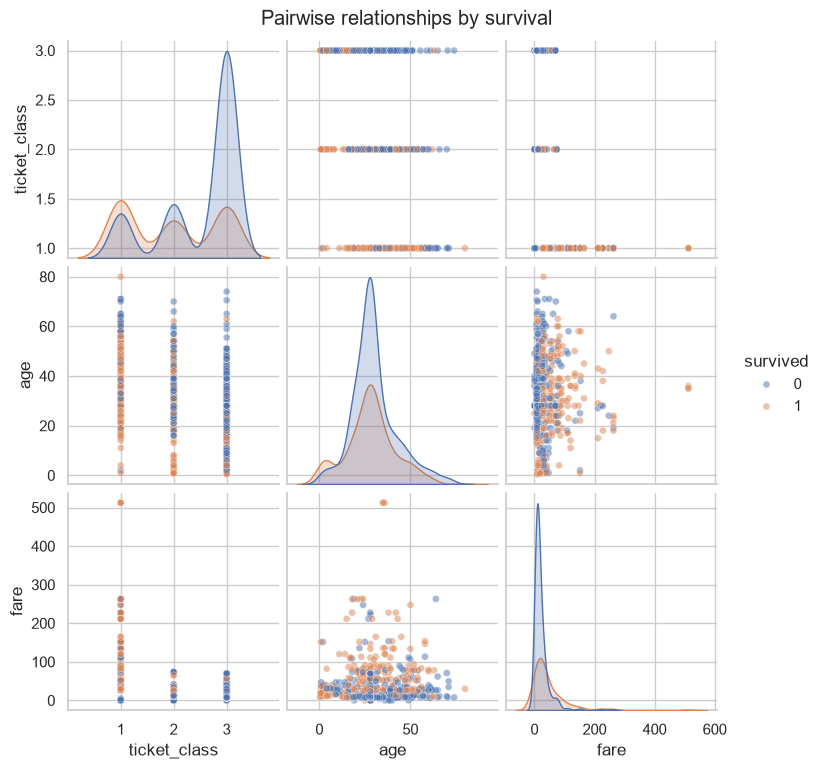

Saved charts/multivariate_pairplot.png

Interpretation:
Survivors cluster at low ticket_class (1st) and high fare; non-survivors cluster at high ticket_class (3rd) and low fare. This visually confirms the negative ticket_class<->fare correlation and the positive fare<->survived signal.


In [23]:
scatter_cols = ["survived", "ticket_class", "age", "fare"]
g = sns.pairplot(
    df[scatter_cols + ["sex"]],
    hue="survived",
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 25},
    height=2.5,
)
g.figure.suptitle("Pairwise relationships by survival", y=1.02)
g.savefig("charts/multivariate_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/multivariate_pairplot.png")

print("\nInterpretation:")
print("Survivors cluster at low ticket_class (1st) and high fare; non-survivors cluster at high ticket_class (3rd) and low fare. This visually confirms the negative ticket_class<->fare correlation and the positive fare<->survived signal.")

## 12. Multivariate chart - Age distribution faceted by sex and ticket_class, colored by survival

Faceted histograms (sex x ticket_class) for `age`, filled by `survived`. Reveals how survival varies jointly across sex, class, and age band.

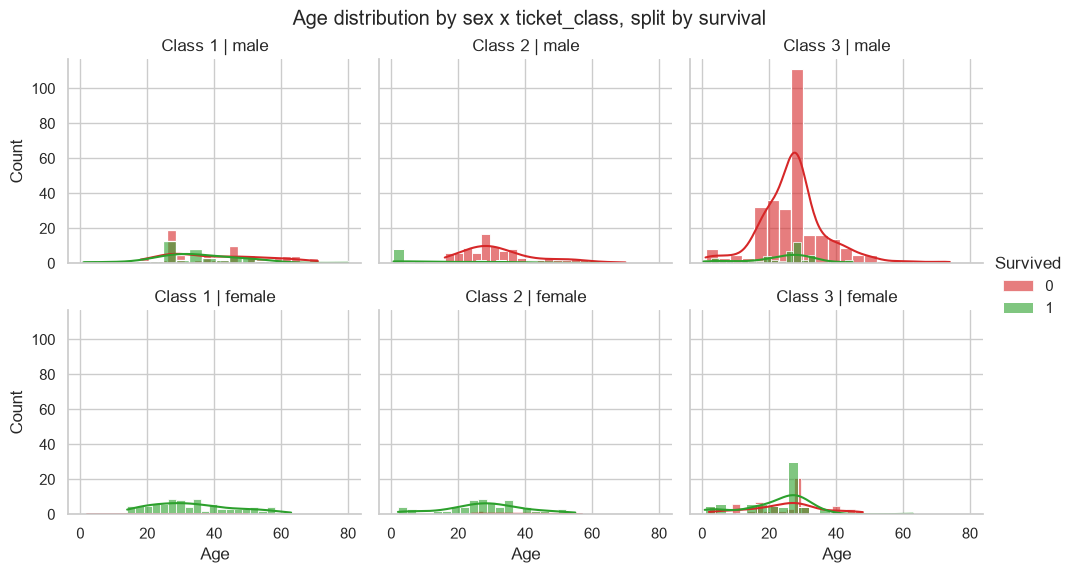

Saved charts/multivariate_facet_age.png

Interpretation:
Female 1st-class survival is nearly universal; female 3rd-class survival drops sharply. Male survival is low across all classes. Among males, very young children in 1st/2nd class show higher survival - children were prioritized.


In [24]:
g = sns.FacetGrid(
    df, col="ticket_class", row="sex", hue="survived",
    height=2.8, aspect=1.2, palette={0: "#d62728", 1: "#2ca02c"},
    legend_out=True,
)
g.map(sns.histplot, "age", bins=20, alpha=0.6, kde=True)
g.add_legend(title="Survived")
g.set_axis_labels("Age", "Count")
g.set_titles("Class {col_name} | {row_name}")
g.figure.suptitle("Age distribution by sex x ticket_class, split by survival", y=1.02)
g.savefig("charts/multivariate_facet_age.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/multivariate_facet_age.png")

print("\nInterpretation:")
print("Female 1st-class survival is nearly universal; female 3rd-class survival drops sharply. Male survival is low across all classes. Among males, very young children in 1st/2nd class show higher survival - children were prioritized.")

## 13. Multivariate chart - Fare by ticket_class and survival

Split violin showing the fare distribution per ticket_class, split by survival. Captures how fare, class, and survival interact on a log scale (necessary because fare is right-skewed).

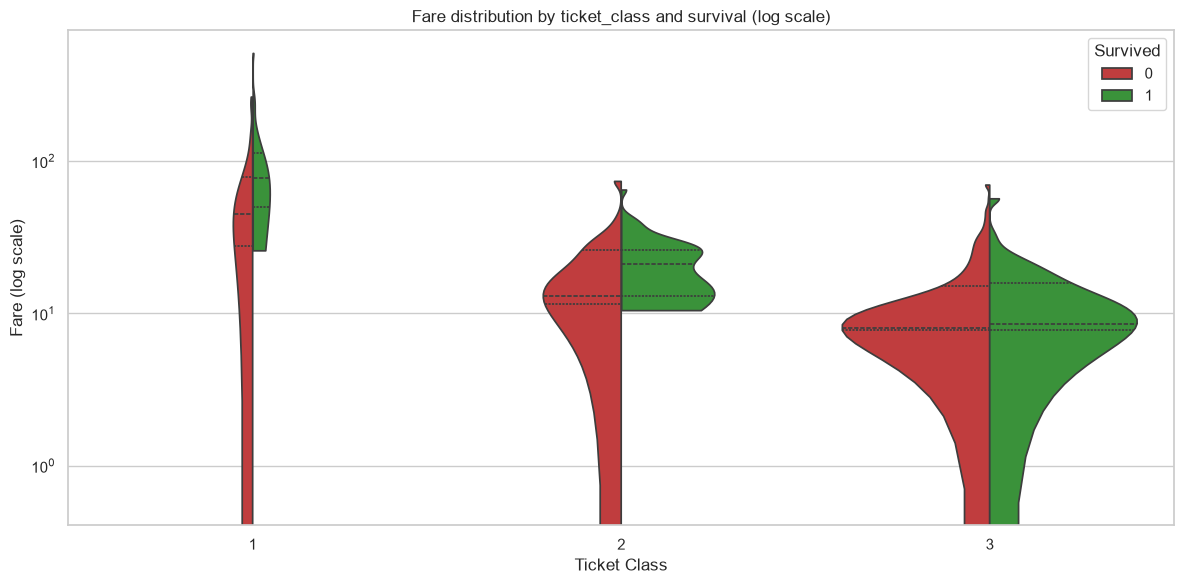

Saved charts/multivariate_violin_fare.png

Interpretation:
Within each class, survivors tend to have paid slightly higher fares than non-survivors, but the dominant separation is between classes. The class effect dominates the fare effect on survival; fare adds only marginal signal once class is known.


In [25]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df, x="ticket_class", y="fare", hue="survived",
    split=True, inner="quart", palette={0: "#d62728", 1: "#2ca02c"},
    cut=0,
)
plt.yscale("log")
plt.title("Fare distribution by ticket_class and survival (log scale)")
plt.xlabel("Ticket Class")
plt.ylabel("Fare (log scale)")
plt.legend(title="Survived")
plt.tight_layout()
plt.savefig("charts/multivariate_violin_fare.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/multivariate_violin_fare.png")

print("\nInterpretation:")
print("Within each class, survivors tend to have paid slightly higher fares than non-survivors, but the dominant separation is between classes. The class effect dominates the fare effect on survival; fare adds only marginal signal once class is known.")

## 14. Multivariate chart - Survival rate by embark_town, ticket_class, and sex

Grouped bar chart of survival rates, faceted by embark_town, with one group per (ticket_class, sex). Five variables in one view.

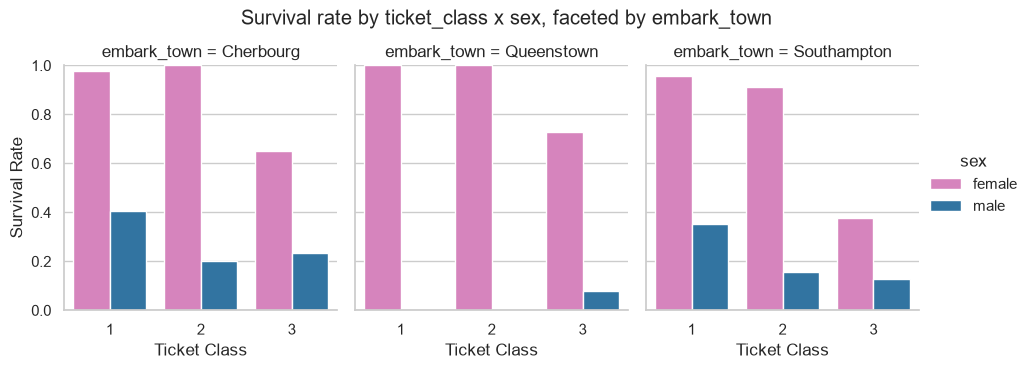

Saved charts/multivariate_survival_by_embark.png

Interpretation:
Female survival is high in Cherbourg and Queenstown across all classes; in Southampton, female 3rd-class survival is markedly lower. Male survival is uniformly low across embarkation ports, with 3rd-class Southampton males faring worst.


In [26]:
group = (
    df.groupby(["embark_town", "ticket_class", "sex"])["survived"]
      .mean()
      .reset_index()
)

g = sns.catplot(
    data=group, x="ticket_class", y="survived",
    hue="sex", col="embark_town",
    kind="bar", palette={"male": "#1f77b4", "female": "#e377c2"},
    height=3.5, aspect=0.9,
)
g.set_axis_labels("Ticket Class", "Survival Rate")
g.set(ylim=(0, 1))
g.figure.suptitle("Survival rate by ticket_class x sex, faceted by embark_town", y=1.05)
g.savefig("charts/multivariate_survival_by_embark.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/multivariate_survival_by_embark.png")

print("\nInterpretation:")
print("Female survival is high in Cherbourg and Queenstown across all classes; in Southampton, female 3rd-class survival is markedly lower. Male survival is uniformly low across embarkation ports, with 3rd-class Southampton males faring worst.")